# 📊 Notebook 01 — Análise Exploratória de Dados (EDA)

**Projeto:** Tech Challenge Fase 1

**Dataset:** Telco Customer Churn

**Objetivo:** Entender a qualidade, distribuição e padrões dos dados antes da modelagem.

---

## Índice
1. [Setup e Carregamento dos Dados](#1-setup)
2. [Visão Geral do Dataset](#2-visao-geral)
3. [Qualidade dos Dados](#3-qualidade)
4. [Análise da Variável Alvo](#4-target)
5. [Features Numéricas](#5-numericas)
6. [Features Categóricas](#6-categoricas)
7. [Correlações e Relações com o Target](#7-correlacoes)
8. [Conclusões](#8-conclusoes)

# 1. Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FIGSIZE = (12, 5)

# Caminho do dataset
data_path = '/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

print('Bibliotecas carregadas com sucesso!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Bibliotecas carregadas com sucesso!
Pandas: 2.0.3 | NumPy: 1.24.1


In [2]:
# Leitura dos dados 

df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

Dataset carregado: 7,043 linhas × 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Visão geral do Dataset

In [3]:
print('-' * 35)
print('INFORMAÇÕES GERAIS')
print('-' * 35)
print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]:}')
print(f'Duplicadas: {df.duplicated().sum()}')
print(f'Memória : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('-' * 35)
print('TIPOS DE DADOS')
print('-' * 35)
print(df.dtypes.value_counts())


-----------------------------------
INFORMAÇÕES GERAIS
-----------------------------------
Linhas: 7,043
Colunas: 21
Duplicadas: 0
Memória : 7975.1 KB

-----------------------------------
TIPOS DE DADOS
-----------------------------------
object     18
int64       2
float64     1
Name: count, dtype: int64


In [ ]:
# Separação das features por tipo de dado
num_list = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_list = df.select_dtypes(include=['object']).columns.tolist()

# Remover colunas para o modelo
id_col = ['customerID']
target_col = ['Churn']

cat_features = [c for c in cat_list if c not in id_col + [target_col]]
num_features = [c for c in num_list if c not in id_col + [target_col]]

print(f'Features numéricas  ({len(num_features)}): {num_features}')
print(f'Features categóricas ({len(cat_features)}): {cat_features}')


Features numéricas  (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Features categóricas (17): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


# 3. Qualidade dos Dados

In [ ]:
# Análise de valores nulos e tipos
quality = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos' : df.isnull().sum(),
    'nulos_%' : (df.isnull().sum() / len(df) * 100).round(2),
    'únicos' : df.nunique(),
    'exemplo' : df.iloc[0]
})

print('QUALIDADE DOS DADOS')
print('-' * 65)
display(quality)

QUALIDADE DOS DADOS
-----------------------------------------------------------------


,dtype,nulos,nulos_%,únicos,exemplo
customerID,object,0,0.0,7043,7590-VHVEG
gender,object,0,0.0,2,Female
SeniorCitizen,int64,0,0.0,2,0
Partner,object,0,0.0,2,Yes
Dependents,object,0,0.0,2,No
tenure,int64,0,0.0,73,1
PhoneService,object,0,0.0,2,No
MultipleLines,object,0,0.0,3,No phone service
InternetService,object,0,0.0,3,DSL
OnlineSecurity,object,0,0.0,3,No


In [ ]:
# TotalCharges: converter para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nulos_total = df['TotalCharges'].isnull().sum()
print(f'⚠️  TotalCharges: {nulos_total} valores nulos após conversão')
print('   → Esses registros são clientes com tenure=0 (recém-adquiridos)')
print()

# Ver registros problemáticos
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

⚠️  TotalCharges: 11 valores nulos após conversão
   → Esses registros são clientes com tenure=0 (recém-adquiridos)



,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN


In [7]:
# ----- Converter target para binário -----
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

print('✅ Target convertido: Yes → 1 | No → 0')
print(f'Distribuição:\n{df["Churn"].value_counts()}')

✅ Target convertido: Yes → 1 | No → 0
Distribuição:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 4. Análise da Variável Alvo (Churn)

In [24]:
churn_counts = df['Churn'].value_counts()
# Verificar o desbalanceameto da variavel target
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print (f'Taxa de ativos: {churn_pct.iloc[0]:.1f}%')
print (f'Taxa de churn: {churn_pct.iloc[1]:.1f}%')


Taxa de ativos: 73.5%
Taxa de churn: 26.5%


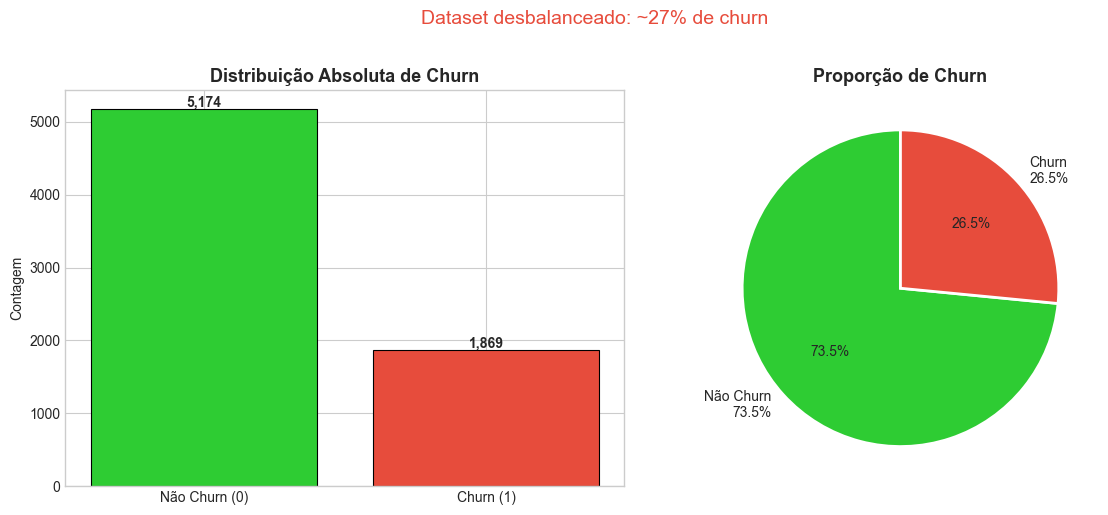

In [31]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Gráfico de barras
colors = ["#2ecc33", '#e74c3c']
axes[0].bar(['Não Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuição Absoluta de Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(churn_pct.values, labels=[f'Não Churn\n{churn_pct.iloc[0]:.1f}%', f'Churn\n{churn_pct.iloc[1]:.1f}%'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção de Churn', fontsize=13, fontweight='bold')

plt.suptitle('Dataset desbalanceado: ~27% de churn', fontsize=14, y=1.02, color='#e74c3c')
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Features Numéricas

In [32]:
display(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


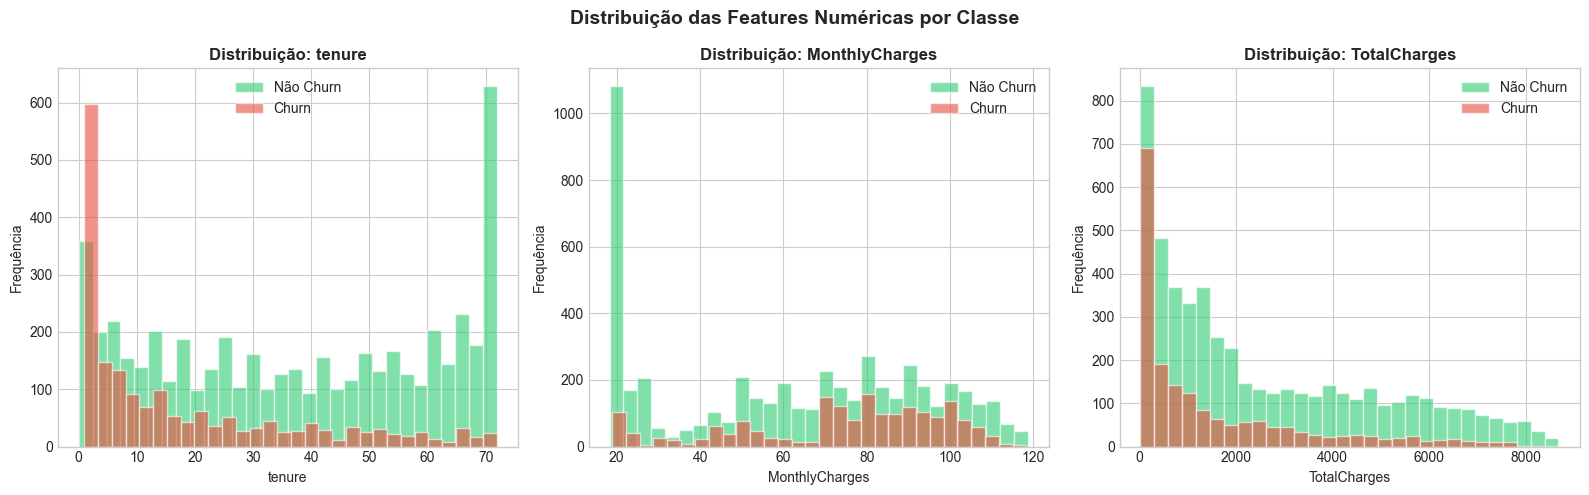

In [36]:
# ----- Distribuição das numéricas por classe de Churn -----
num_plot_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_plot_cols):
    for label, color, name in [(0, '#2ecc71', 'Não Churn'), (1, '#e74c3c', 'Churn')]:
        subset = df[df['Churn'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.suptitle('Distribuição das Features Numéricas por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

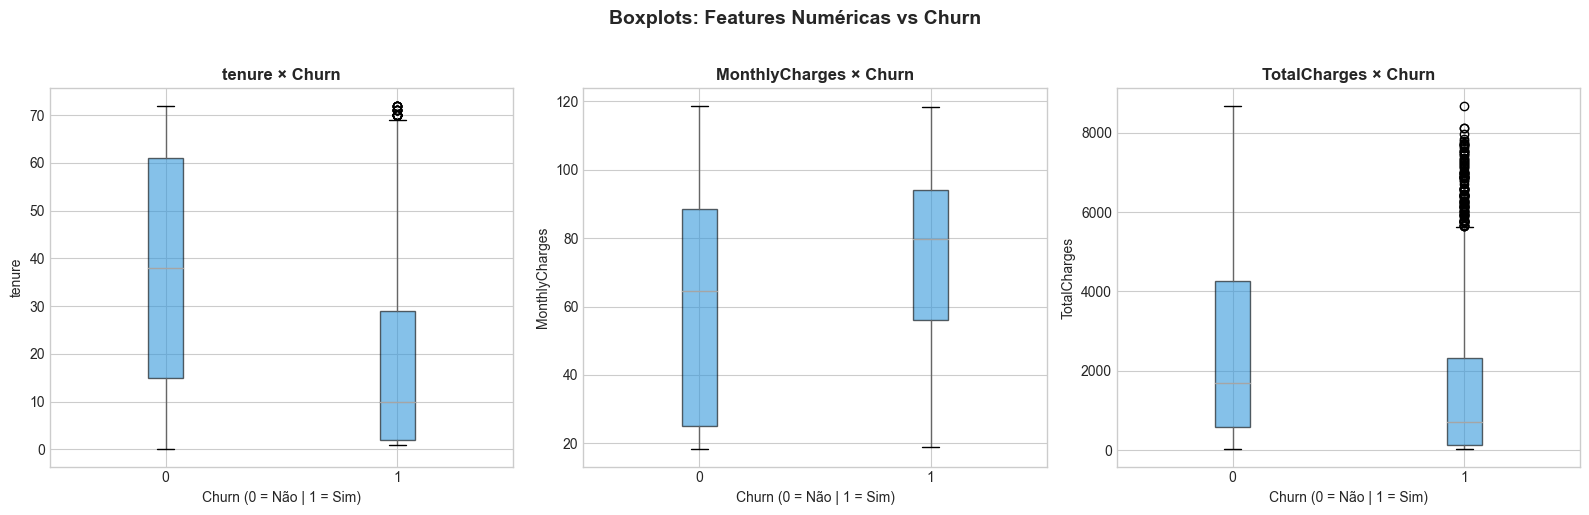

In [37]:
# ----- Boxplot: tenure vs Churn -----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_plot_cols):
    df.boxplot(column=col, by='Churn', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(f'{col} × Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn (0 = Não | 1 = Sim)')
    ax.set_ylabel(col)

plt.suptitle('Boxplots: Features Numéricas vs Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Features Categóricas

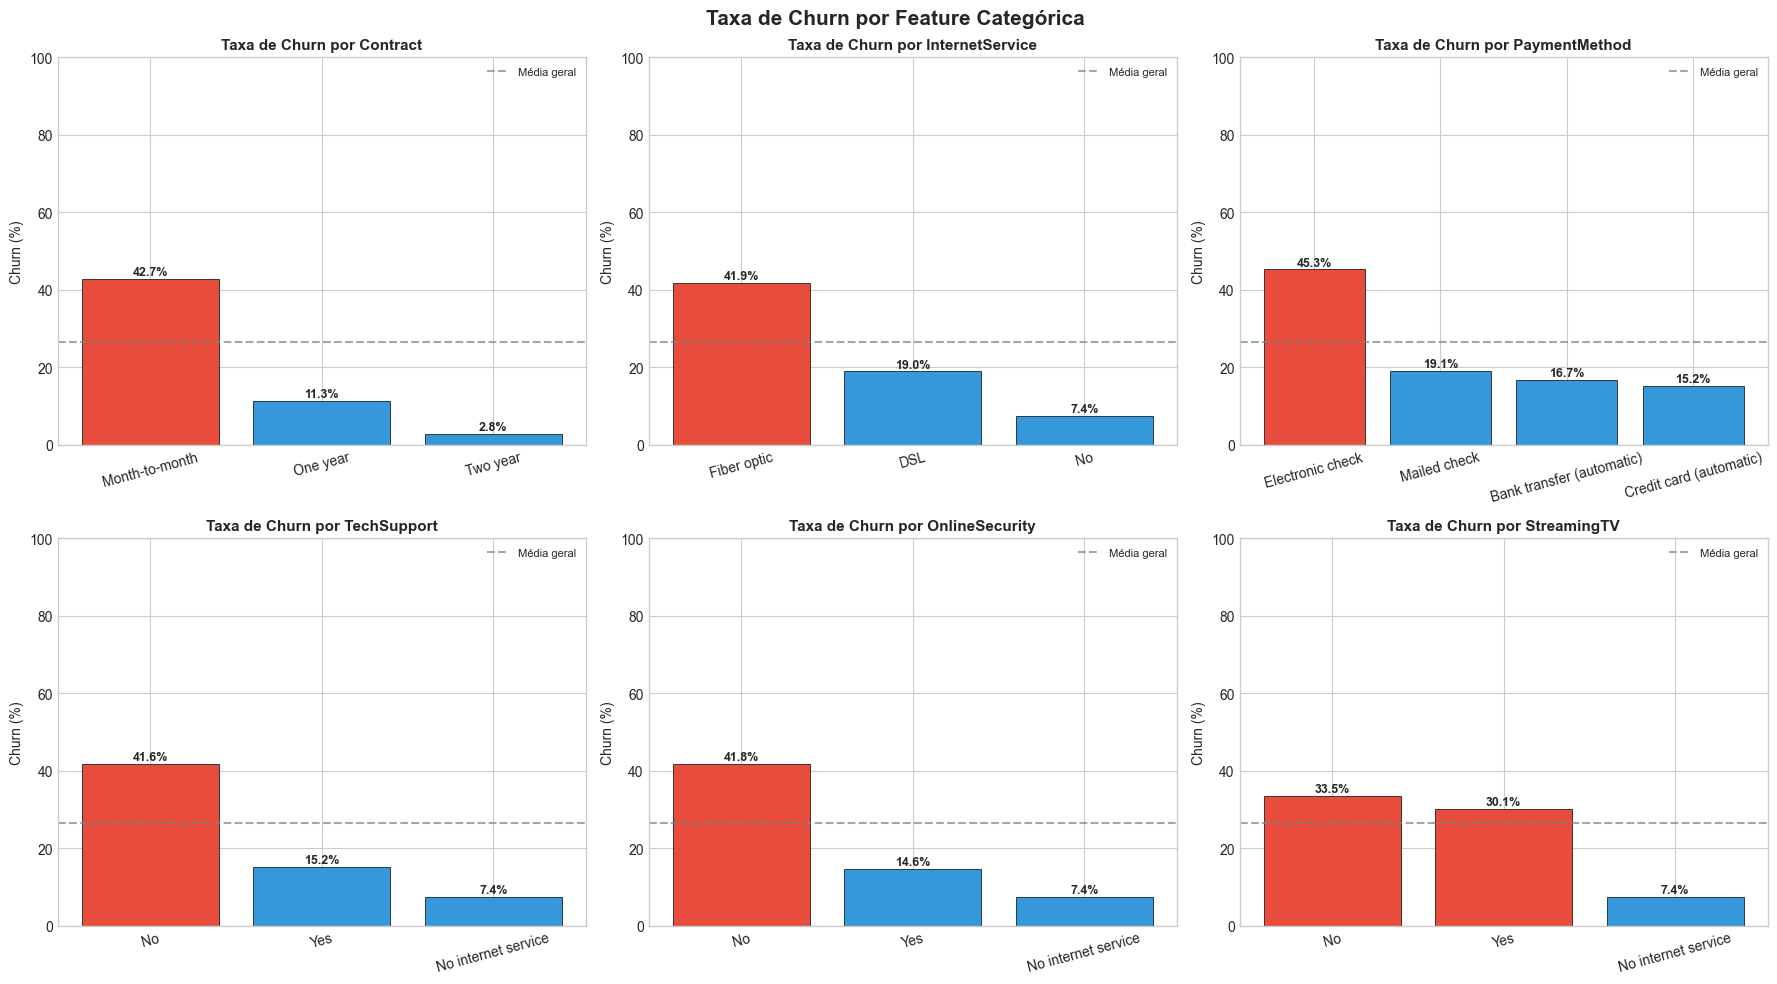

In [39]:
# ----- Taxa de Churn por feature categórica -----
key_cat_features = [
    'Contract', 'InternetService', 'PaymentMethod',
    'TechSupport', 'OnlineSecurity', 'StreamingTV'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_cat_features):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=['#e74c3c' if v > 30 else '#3498db' for v in churn_rate.values],
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f'Taxa de Churn por {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=df['Churn'].mean() * 100, color='gray', linestyle='--', alpha=0.7, label='Média geral')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Taxa de Churn por Feature Categórica', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ----- Tabela de contagem para todas as categóricas -----
print('CONTAGEM DE VALORES ÚNICOS POR FEATURE CATEGÓRICA')
print('=' * 55)
for col in cat_features:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

CONTAGEM DE VALORES ÚNICOS POR FEATURE CATEGÓRICA

gender:
gender
Male      3555
Female    3488

Partner:
Partner
No     3641
Yes    3402

Dependents:
Dependents
No     4933
Yes    2110

PhoneService:
PhoneService
Yes    6361
No      682

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526

TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526

StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    

## 7. Correlações e Relações com o Target

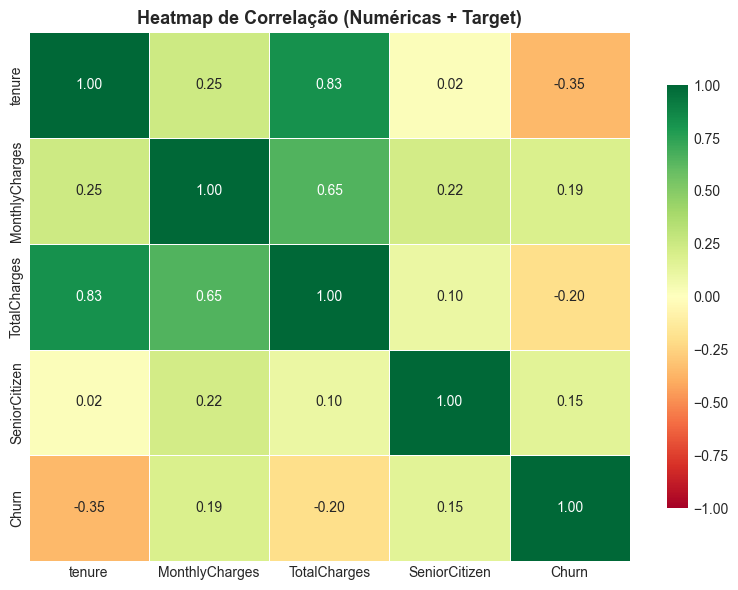

In [42]:
# ----- Heatmap de correlação (features numéricas + target) -----
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap de Correlação (Numéricas + Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


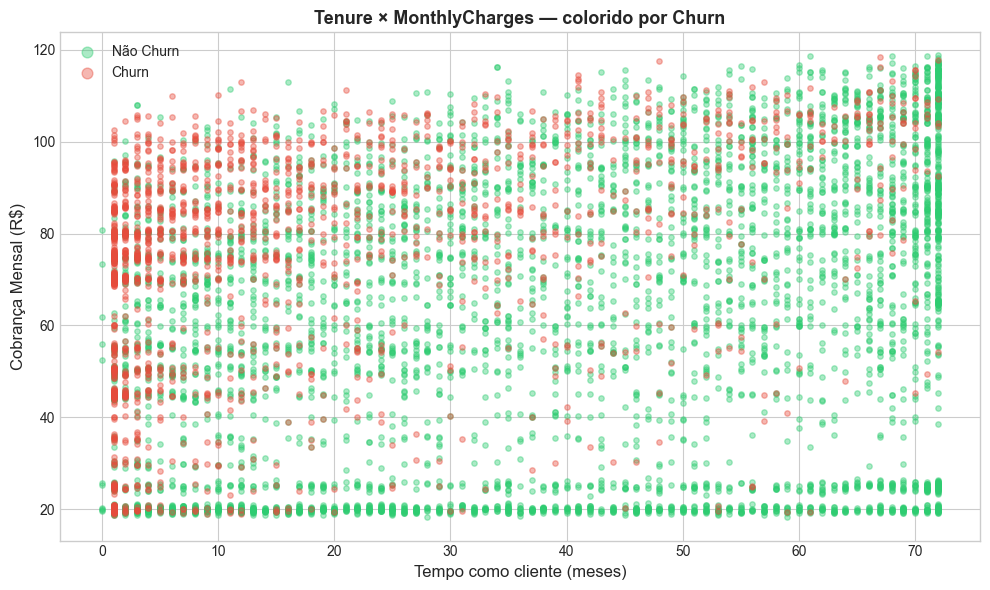

In [44]:
# ----- Scatter: tenure vs MonthlyCharges colorido por Churn -----
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {0: '#2ecc71', 1: '#e74c3c'}
for churn_val, label in [(0, 'Não Churn'), (1, 'Churn')]:
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=colors_map[churn_val], label=label, alpha=0.4, s=15)

ax.set_xlabel('Tempo como cliente (meses)', fontsize=12)
ax.set_ylabel('Cobrança Mensal (R$)', fontsize=12)
ax.set_title('Tenure × MonthlyCharges — colorido por Churn', fontsize=13, fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/docs/eda_scatter_tenure_charges.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusão

In [47]:
print('=' * 60)
print('RELATÓRIO DE DATA READINESS')
print('=' * 60)

total = len(df)
nulos = df.isnull().sum().sum()
dups  = df.duplicated().sum()

print(f'\n📦Volume : {total:,} registros | {df.shape[1]} features')
print(f'Valores nulos : {nulos} ({nulos/total*100:.2f}%) — apenas TotalCharges com tenure=0')
print(f'Duplicatas : {dups}')
print(f'Desbalanceamento: {df["Churn"].mean()*100:.1f}% de churn (classe minoritária)')
print()
print('Desbalanceamento: usar class_weight="balanced" no treino')
print('TotalCharges e tenure: alta correlação, avaliar remover TotalCharges (que representa tenure x valor pago mes)')
print('Features categóricas: 15 colunas, fazer OneHotEncoder')
print()
print('=' * 60)
print('✅ DATASET PRONTO PARA MODELAGEM')
print('=' * 60)

RELATÓRIO DE DATA READINESS

📦Volume : 7,043 registros | 21 features
Valores nulos : 11 (0.16%) — apenas TotalCharges com tenure=0
Duplicatas : 0
Desbalanceamento: 26.5% de churn (classe minoritária)

Desbalanceamento: usar class_weight="balanced" no treino
TotalCharges e tenure: alta correlação, avaliar remover TotalCharges (que representa tenure x valor pago mes)
Features categóricas: 15 colunas, fazer OneHotEncoder

✅ DATASET PRONTO PARA MODELAGEM


In [48]:
# ----- Salvar dataset tratado -----
df.to_csv('/Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/data/processed/telco_churn_clean.csv', index=False)
print('✅ Dataset limpo salvo em: data/processed/telco_churn_clean.csv')
print(f'   Shape final: {df.shape}')

✅ Dataset limpo salvo em: data/processed/telco_churn_clean.csv
   Shape final: (7043, 21)
